In [1]:
import pandas as pd
from pathlib import Path
import numpy as np


In [2]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("/home/jovyan/Desktop/IDX intern/california")

target_months = [
    "202502",
    "202503",
    "202504",
    "202505",
    "202506",
    "202507",
    "202508",
    "202509",
    "202510",
    "202511",
    "202512",
    "202601",
    "202602",
    "202603",
    "202604",
    "202605",
]

files = sorted(
    [
        f
        for f in DATA_DIR.glob("CRMLSSold*.csv")
        if any(f.name.startswith(f"CRMLSSold{m}") for m in target_months)
    ]
)

print(f"Found {len(files)} files (expecting 19):")
for f in files:
    print(f"  {f.name}")


Found 16 files (expecting 19):
  CRMLSSold202502.csv
  CRMLSSold202503.csv
  CRMLSSold202504.csv
  CRMLSSold202505.csv
  CRMLSSold202506.csv
  CRMLSSold202507.csv
  CRMLSSold202508.csv
  CRMLSSold202509.csv
  CRMLSSold202510.csv
  CRMLSSold202511.csv
  CRMLSSold202512.csv
  CRMLSSold202601.csv
  CRMLSSold202602.csv
  CRMLSSold202603.csv
  CRMLSSold202604.csv
  CRMLSSold202605.csv


In [3]:
dfs = []
for f in files:
    try:
        tmp = pd.read_csv(f, low_memory=False)
        tmp = tmp[
            (tmp["PropertyType"] == "Residential")
            & (tmp["PropertySubType"] == "SingleFamilyResidence")
        ].copy()
        tmp["source_file"] = f.name
        dfs.append(tmp)
    except Exception as e:
        print(f"  ✗ {f.name}: {e}")

df = pd.concat(dfs, ignore_index=True)
df["CloseDate"] = pd.to_datetime(df["CloseDate"])

print(f"Total shape: {df.shape}")
print(f"Date range: {df['CloseDate'].min()} ~ {df['CloseDate'].max()}")

monthly_counts = df["CloseDate"].dt.to_period("M").value_counts().sort_index()
print(monthly_counts)

Total shape: (173338, 79)
Date range: 2025-02-01 00:00:00 ~ 2026-05-31 00:00:00
CloseDate
2025-02     8851
2025-03    10610
2025-04    11880
2025-05    11777
2025-06    11701
2025-07    12114
2025-08    11454
2025-09    11456
2025-10    12029
2025-11     9739
2025-12    10455
2026-01     7490
2026-02     8550
2026-03    11177
2026-04    12031
2026-05    12024
Freq: M, Name: count, dtype: int64


## Feature selection lists

In [4]:
location_features = [
    "Latitude",
    "Longitude",
    "City",
    "PostalCode",
    "CountyOrParish",
    "MLSAreaMajor",
    "HighSchoolDistrict",
]

property_features = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "YearBuilt",
    "Stories",
    "ViewYN",
    "PoolPrivateYN",
    "AttachedGarageYN",
    "GarageSpaces",
    "ParkingTotal",
]

lots_financial_final_features = [
    "AssociationFee",
    "LotSizeSquareFeet",
    "LotSizeAcres",
    "LotSizeArea",
]

all_features = location_features + property_features + lots_financial_final_features
print(f"Total features: {len(all_features)}")
print(df[all_features].dtypes)

Total features: 21
Latitude                 float64
Longitude                float64
City                      object
PostalCode                object
CountyOrParish            object
MLSAreaMajor              object
HighSchoolDistrict        object
LivingArea               float64
BedroomsTotal            float64
BathroomsTotalInteger    float64
YearBuilt                float64
Stories                  float64
ViewYN                    object
PoolPrivateYN             object
AttachedGarageYN          object
GarageSpaces             float64
ParkingTotal             float64
AssociationFee           float64
LotSizeSquareFeet        float64
LotSizeAcres             float64
LotSizeArea              float64
dtype: object


## ClosePrice

In [5]:
target = "ClosePrice"
df["log_price"] = np.where(df["ClosePrice"] > 0, np.log(df["ClosePrice"]), np.nan)
print("ClosePrice <= 0:", (df["ClosePrice"] <= 0).sum())
print("ClosePrice isna:", df["ClosePrice"].isna().sum())
print("log_price inf/-inf:", np.isinf(df["log_price"]).sum())
print("log_price isna:", df["log_price"].isna().sum())


ClosePrice <= 0: 1
ClosePrice isna: 0
log_price inf/-inf: 0
log_price isna: 1


/opt/base-uv/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [6]:
print(
    df[(df["ClosePrice"] <= 0) | (df["ClosePrice"].isna())][
        [
            "ClosePrice",
            "ListPrice",
            "City",
            "CountyOrParish",
            "CloseDate",
            "source_file",
        ]
    ]
)


       ClosePrice  ListPrice         City CountyOrParish  CloseDate  \
57331         0.0  1350000.0  Temple City    Los Angeles 2025-07-30   

               source_file  
57331  CRMLSSold202507.csv  


In [7]:
print(f"Before dropping: {len(df)}")
df = df[df["ClosePrice"] > 0].copy()
print(f"After dropping: {len(df)}")


Before dropping: 173338
After dropping: 173337


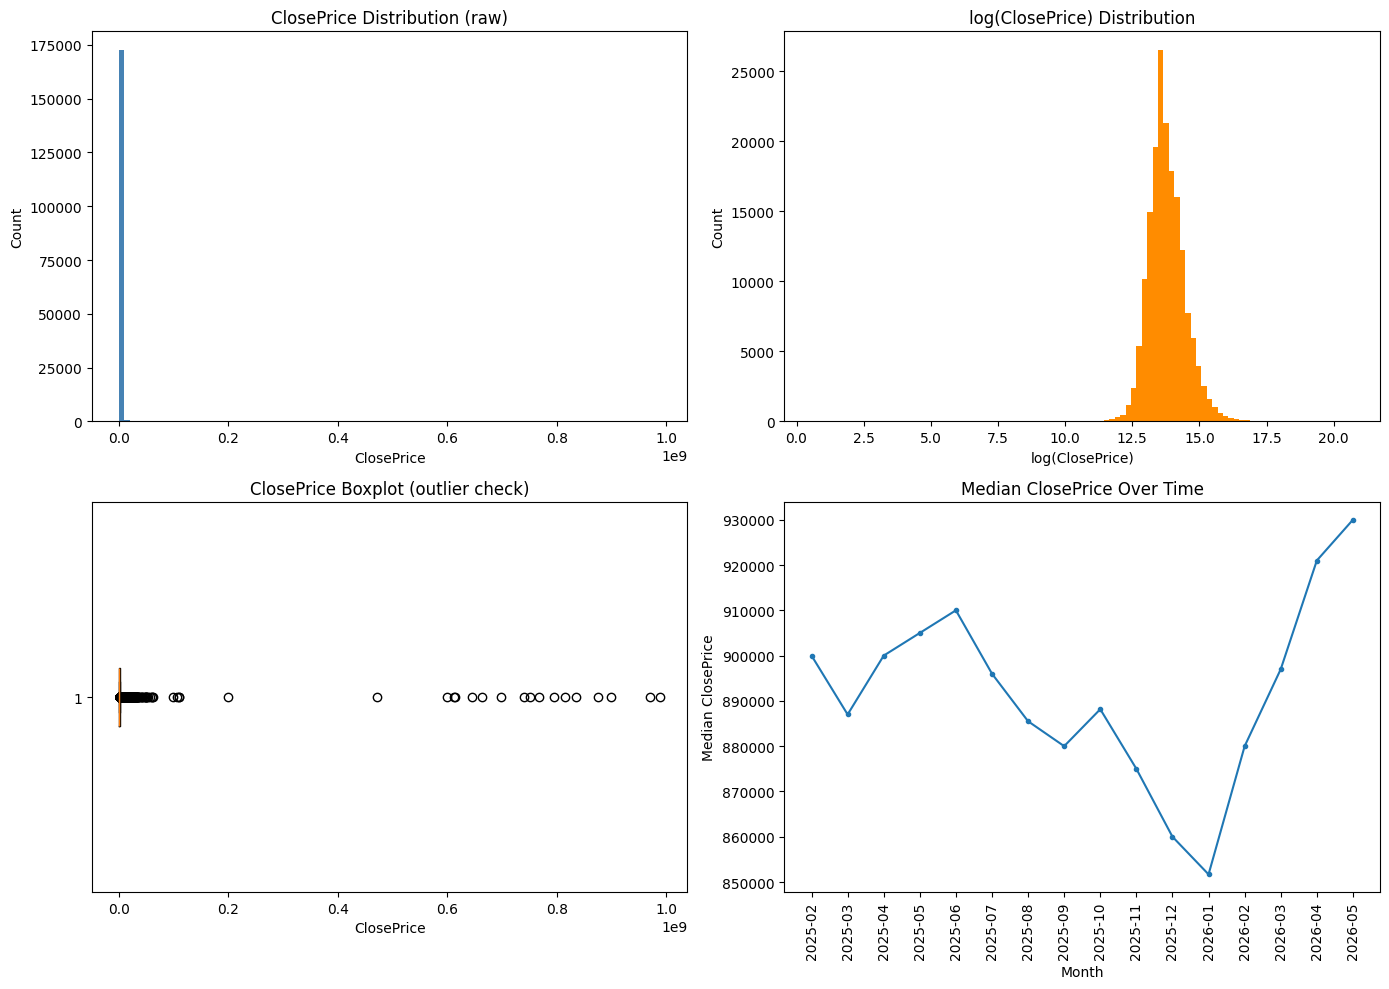

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df["ClosePrice"], bins=100, color="steelblue", edgecolor="none")
axes[0, 0].set_title("ClosePrice Distribution (raw)")
axes[0, 0].set_xlabel("ClosePrice")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(df["log_price"], bins=100, color="darkorange", edgecolor="none")
axes[0, 1].set_title("log(ClosePrice) Distribution")
axes[0, 1].set_xlabel("log(ClosePrice)")
axes[0, 1].set_ylabel("Count")

axes[1, 0].boxplot(df["ClosePrice"].dropna(), vert=False)
axes[1, 0].set_title("ClosePrice Boxplot (outlier check)")
axes[1, 0].set_xlabel("ClosePrice")

monthly_median = df.groupby(df["CloseDate"].dt.to_period("M"))["ClosePrice"].median()
axes[1, 1].plot(
    monthly_median.index.astype(str), monthly_median.values, marker="o", markersize=3
)
axes[1, 1].set_title("Median ClosePrice Over Time")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Median ClosePrice")
axes[1, 1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


In [9]:
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", None)

df["price_ratio"] = df["ClosePrice"] / df["ListPrice"]

check_cols = [
    "ClosePrice",
    "ListPrice",
    "price_ratio",
    "City",
    "CountyOrParish",
    "LivingArea",
    "CloseDate",
]

print("Top 20 highest price_ratio:")
print(df.nlargest(20, "price_ratio")[check_cols])

print("\nTop 20 lowest price_ratio:")
print(df.nsmallest(20, "price_ratio")[check_cols])


Top 20 highest price_ratio:
           ClosePrice     ListPrice  price_ratio           City  CountyOrParish  LivingArea  CloseDate
78806  751,412,000.00    699,000.00     1,074.98        La Mesa       San Diego      798.00 2025-09-26
159163 768,500,000.00    750,000.00     1,024.67      San Diego       San Diego    1,444.00 2026-04-09
92297  989,500,000.00    979,000.00     1,010.73       Valencia     Los Angeles    2,289.00 2025-10-31
87203  815,000,000.00    809,000.00     1,007.42         Saugus     Los Angeles    1,900.00 2025-09-10
109072 740,000,000.00    735,000.00     1,006.80      San Diego       San Diego    1,271.00 2025-11-24
78429  875,000,000.00    875,000.00     1,000.00      San Diego       San Diego    1,730.00 2025-09-25
81277  835,800,000.00    835,800.00     1,000.00         Ramona       San Diego      718.00 2025-09-11
131139 699,000,000.00    699,000.00     1,000.00         Ramona       San Diego    2,114.00 2026-02-24
155951 645,000,000.00    645,000.00     1,000

In [10]:
pd.set_option("display.float_format", "{:,.4f}".format)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", None)

df["price_ratio"] = df["ClosePrice"] / df["ListPrice"]

print(df["price_ratio"].describe())
print("\nPercentiles:")
print(
    df["price_ratio"].quantile(
        [
            0.0001,
            0.0005,
            0.001,
            0.005,
            0.01,
            0.05,
            0.5,
            0.95,
            0.99,
            0.995,
            0.999,
            0.9995,
            0.9999,
        ]
    )
)


count   173,337.0000
mean          1.0983
std           9.5406
min           0.0000
25%           0.9745
50%           1.0000
75%           1.0182
max       1,074.9814
Name: price_ratio, dtype: float64

Percentiles:
0.0001     0.0968
0.0005     0.5000
0.0010     0.6446
0.0050     0.7880
0.0100     0.8343
0.0500     0.9165
0.5000     1.0000
0.9500     1.1092
0.9900     1.2796
0.9950     1.3819
0.9990     1.6772
0.9995     1.9492
0.9999   107.8164
Name: price_ratio, dtype: float64


## Geographic distribution

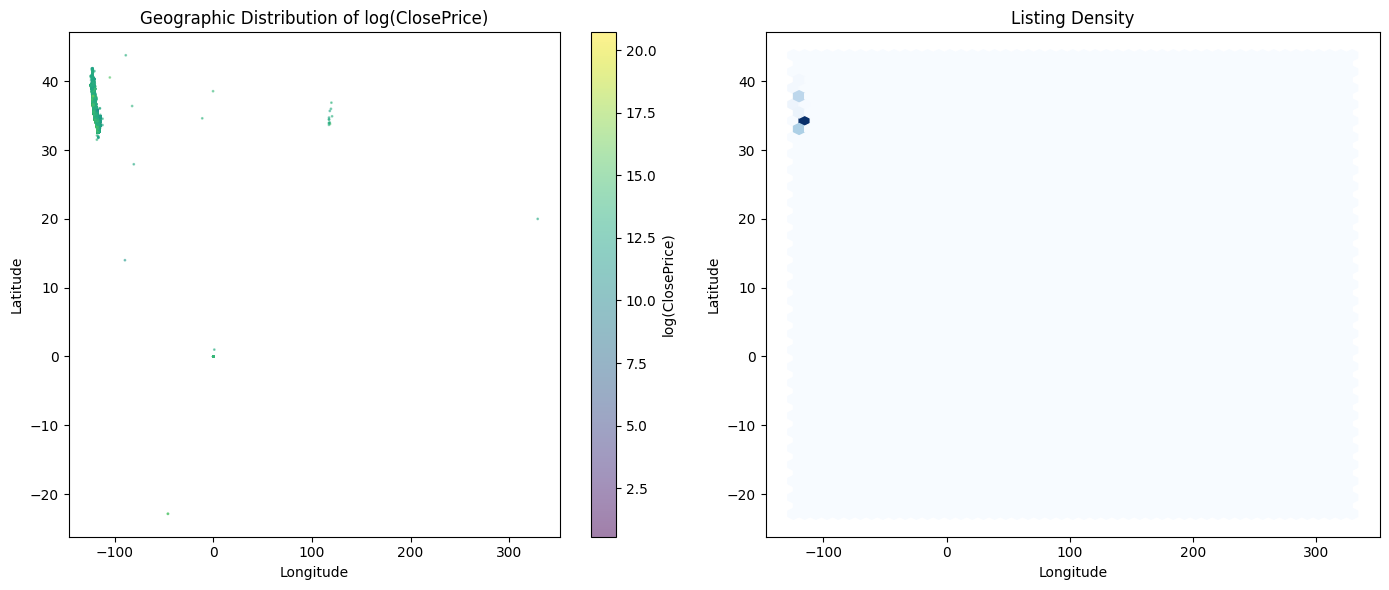

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter = axes[0].scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["log_price"],
    cmap="viridis",
    s=1,
    alpha=0.5,
)
axes[0].set_title("Geographic Distribution of log(ClosePrice)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
plt.colorbar(scatter, ax=axes[0], label="log(ClosePrice)")

axes[1].hexbin(df["Longitude"], df["Latitude"], gridsize=50, cmap="Blues")
axes[1].set_title("Listing Density")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()


In [12]:
# Check for coordinates outside California's valid range
# California roughly: lat 32-42, lon -125 to -114
invalid_coords = df[
    (df["Latitude"] < 31.0)
    | (df["Latitude"] > 45)
    | (df["Longitude"] < -125.0)
    | (df["Longitude"] > -113.5)
]
print(f"Invalid coordinate count: {len(invalid_coords)}")
print(
    invalid_coords[
        ["Latitude", "Longitude", "City", "CountyOrParish", "ClosePrice"]
    ].head(20)
)


Invalid coordinate count: 45
        Latitude  Longitude                       City   CountyOrParish     ClosePrice
10976    36.4045   -82.3565  Outside Area (Outside Ca)      Other State   745,000.0000
12374    20.0000   329.0000                   Hesperia   San Bernardino   355,000.0000
28182     0.0000     0.0000                    Compton      Los Angeles   520,000.0000
28994     0.0000     0.0000                  Los Gatos      Santa Clara 3,210,000.0000
29851     0.0000     0.0000                    Manteca      San Joaquin   762,000.0000
42589    40.5556  -104.9546                        NaN            Other 4,050,000.0000
52502    27.9429   -80.6551                      Other            Other   325,000.0000
53270    34.4800   117.3100                Victorville   San Bernardino   490,000.0000
53523     1.0000     1.0000                   Beaumont        Riverside   511,000.0000
66477     0.0000     0.0000                  Los Gatos      Santa Clara 3,517,000.0000
71100    38.56

In [13]:
sign_flip_mask = (
    (df["Latitude"] >= 32)
    & (df["Latitude"] <= 42)
    & (df["Longitude"] > 0)
    & (-df["Longitude"] >= -125)
    & (-df["Longitude"] <= -114)
)
print(f"Sign-flip fixable count: {sign_flip_mask.sum()}")
print(df.loc[sign_flip_mask, ["Latitude", "Longitude", "City", "CountyOrParish"]])
df.loc[sign_flip_mask, "Longitude"] = -df.loc[sign_flip_mask, "Longitude"]

Sign-flip fixable count: 12
        Latitude  Longitude                  City  CountyOrParish
53270    34.4800   117.3100           Victorville  San Bernardino
74353    33.8006   118.3901  Palos Verdes Estates     Los Angeles
86024    36.0000   119.3000               Visalia          Tulare
89409    36.8931   119.7605                Fresno          Fresno
106246   34.0187   118.0658           Pico Rivera     Los Angeles
107152   34.9169   120.4327           Santa Maria   Santa Barbara
108840   33.6677   117.2708         Lake Elsinore       Riverside
109425   33.9373   117.2601         Moreno Valley       Riverside
124130   34.4231   117.3663              Hesperia  San Bernardino
130275   35.6911   118.1400             Lancaster     Los Angeles
152309   33.9207   117.4675             Riverside       Riverside
153245   34.7287   117.3431             Helendale  San Bernardino


In [14]:
invalid_coords = df[
    (df["Latitude"] < 31.0)
    | (df["Latitude"] > 45)
    | (df["Longitude"] < -125.0)
    | (df["Longitude"] > -113.5)
]
print(f"Invalid coordinate count: {len(invalid_coords)}")
print(invalid_coords[["Latitude", "Longitude", "City", "CountyOrParish", "ClosePrice"]])


Invalid coordinate count: 33
        Latitude  Longitude                       City   CountyOrParish     ClosePrice
10976    36.4045   -82.3565  Outside Area (Outside Ca)      Other State   745,000.0000
12374    20.0000   329.0000                   Hesperia   San Bernardino   355,000.0000
28182     0.0000     0.0000                    Compton      Los Angeles   520,000.0000
28994     0.0000     0.0000                  Los Gatos      Santa Clara 3,210,000.0000
29851     0.0000     0.0000                    Manteca      San Joaquin   762,000.0000
42589    40.5556  -104.9546                        NaN            Other 4,050,000.0000
52502    27.9429   -80.6551                      Other            Other   325,000.0000
53523     1.0000     1.0000                   Beaumont        Riverside   511,000.0000
66477     0.0000     0.0000                  Los Gatos      Santa Clara 3,517,000.0000
71100    38.5628    -0.2626             Mountain House      San Joaquin 1,240,000.0000
78190    33.64

In [15]:
df = df[~df.index.isin(invalid_coords.index)].copy()
print(f"Final row count: {len(df)}")


Final row count: 173304


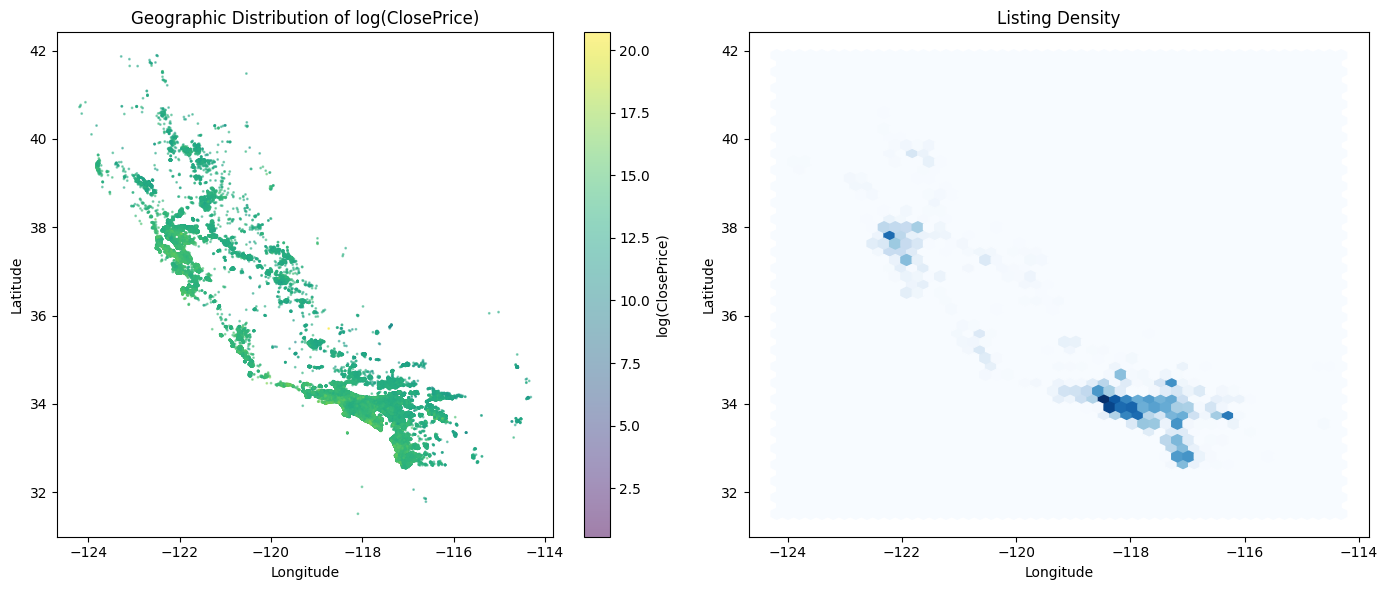

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter = axes[0].scatter(
    df["Longitude"], df["Latitude"], c=df["log_price"], cmap="viridis", s=1, alpha=0.5
)
axes[0].set_title("Geographic Distribution of log(ClosePrice)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
plt.colorbar(scatter, ax=axes[0], label="log(ClosePrice)")

axes[1].hexbin(df["Longitude"], df["Latitude"], gridsize=50, cmap="Blues")
axes[1].set_title("Listing Density")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()


## Missing rate

In [17]:
print(f"ClosePrice missing count: {df['ClosePrice'].isna().sum()}")
print(f"ClosePrice missing pct: {df['ClosePrice'].isna().mean() * 100:.4f}%")


ClosePrice missing count: 0
ClosePrice missing pct: 0.0000%


In [18]:
missing_summary = df[all_features].isna().mean().sort_values(ascending=False) * 100
missing_summary = missing_summary.round(2).to_frame("missing_pct")
missing_summary["dtype"] = df[all_features].dtypes.astype(str)
print(missing_summary)


                       missing_pct    dtype
AssociationFee             29.1400  float64
HighSchoolDistrict         26.9600   object
MLSAreaMajor               14.5300   object
AttachedGarageYN           12.0400   object
Stories                    10.6200  float64
ViewYN                      9.0300   object
PoolPrivateYN               7.8000   object
GarageSpaces                3.9300  float64
LotSizeAcres                1.7300  float64
LotSizeSquareFeet           1.7300  float64
LotSizeArea                 1.7200  float64
YearBuilt                   0.0700  float64
LivingArea                  0.0500  float64
City                        0.0400   object
BathroomsTotalInteger       0.0100  float64
Longitude                   0.0100  float64
Latitude                    0.0100  float64
PostalCode                  0.0000   object
ParkingTotal                0.0000  float64
BedroomsTotal               0.0000  float64
CountyOrParish              0.0000   object


### AssociationFee

In [19]:
print(df["AssociationFee"].describe())
print((df["AssociationFee"] == 0).sum())


count   122,807.0000
mean        106.3458
std         336.9063
min           0.0000
25%           0.0000
50%           0.0000
75%         131.7850
max      20,712.0000
Name: AssociationFee, dtype: float64
78218


In [20]:
df["AssociationFee_missing"] = df["AssociationFee"].isna().astype(int)
df["AssociationFee"] = df["AssociationFee"].fillna(0)


### HighSchoolDistrict, MLSAreaMajor


In [21]:
# Check highest missing rate for HighSchoolDistrict
missing_by_county_hsd = df.groupby("CountyOrParish")["HighSchoolDistrict"].apply(
    lambda x: x.isna().mean() * 100
)
print("Top 10 counties with highest missing rate for HighSchoolDistrict:")
print(missing_by_county_hsd.sort_values(ascending=False))


Top 10 counties with highest missing rate for HighSchoolDistrict:
CountyOrParish
Other             100.0000
Amador             92.3077
Trinity            90.0000
Mendocino          84.6491
Solano             81.6527
Contra Costa       73.4035
San Joaquin        71.9553
Napa               71.1538
Yolo               70.2703
Sonoma             69.6970
Marin              68.4211
Alameda            67.2276
Mono               66.6667
Ventura            65.3853
Placer             62.7660
Nevada             62.5000
Sacramento         62.3256
Calaveras          60.8696
El Dorado          59.0909
Tuolumne           58.6207
Imperial           57.7236
San Diego          52.5358
San Francisco      44.1176
Stanislaus         36.7089
Shasta             32.7586
Humboldt           28.5714
Santa Barbara      26.7375
Los Angeles        25.2307
Riverside          22.1660
Colusa             16.6667
Kern               12.7604
Lassen             11.1111
Siskiyou            9.6774
Sutter              8.7719
P

In [22]:
# Check highest missing rate for MLSAreaMajor
missing_by_county_mls = df.groupby("CountyOrParish")["MLSAreaMajor"].apply(
    lambda x: x.isna().mean() * 100
)
print("\nTop 10 counties with highest missing rate for MLSAreaMajor:")
print(missing_by_county_mls.sort_values(ascending=False))



Top 10 counties with highest missing rate for MLSAreaMajor:
CountyOrParish
Other             100.0000
Trinity           100.0000
Clark             100.0000
Amador            100.0000
San Francisco      98.5294
Sutter             98.2456
Contra Costa       97.7857
Butte              97.0460
Merced             94.6078
Alameda            94.5278
Glenn              93.5961
Siskiyou           93.5484
Calaveras          93.4783
Yuba               93.2432
Tuolumne           93.1034
Kings              90.3226
Lassen             88.8889
Shasta             87.9310
Solano             87.6751
Tulare             86.8932
Napa               84.6154
Yolo               83.7838
Colusa             83.3333
Nevada             83.3333
San Joaquin        82.0112
Tehama             81.6327
Sonoma             80.3030
Sacramento         80.0000
Stanislaus         79.7468
Fresno             75.8717
Placer             75.5319
Inyo               75.0000
Marin              71.9298
Humboldt           71.4286
Plumas

In [23]:
# 1 is missing, 0 is not missing
for col in ["HighSchoolDistrict", "MLSAreaMajor"]:
    df[f"{col}_missing"] = df[col].isna().astype(int)
    df[col] = df[col].fillna("Missing")

print(
    df[
        [
            "HighSchoolDistrict",
            "HighSchoolDistrict_missing",
            "MLSAreaMajor",
            "MLSAreaMajor_missing",
        ]
    ]
    .isna()
    .sum()
)


HighSchoolDistrict            0
HighSchoolDistrict_missing    0
MLSAreaMajor                  0
MLSAreaMajor_missing          0
dtype: int64


### ViewYN, PoolPrivateYN, AttachedGarageYN

In [24]:
for col in ["ViewYN", "PoolPrivateYN", "AttachedGarageYN"]:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


ViewYN:
ViewYN
True     97224
False    60424
NaN      15656
Name: count, dtype: int64

PoolPrivateYN:
PoolPrivateYN
False    132813
True      26969
NaN       13522
Name: count, dtype: int64

AttachedGarageYN:
AttachedGarageYN
True     127307
False     25126
NaN       20871
Name: count, dtype: int64


In [25]:
for col in ["ViewYN", "PoolPrivateYN", "AttachedGarageYN"]:
    df[f"{col}_missing"] = df[col].isna().astype(int)
    df[col] = df[col].astype(object).fillna("Missing")

print(
    df[
        [
            "ViewYN",
            "ViewYN_missing",
            "PoolPrivateYN",
            "PoolPrivateYN_missing",
            "AttachedGarageYN",
            "AttachedGarageYN_missing",
        ]
    ]
    .isna()
    .sum()
)

ViewYN                      0
ViewYN_missing              0
PoolPrivateYN               0
PoolPrivateYN_missing       0
AttachedGarageYN            0
AttachedGarageYN_missing    0
dtype: int64


### Stories

In [26]:
print(df["Stories"].describe())
print(df["Stories"].value_counts(dropna=False).sort_index())


count   154,892.0000
mean          1.3517
std           0.4775
min           1.0000
25%           1.0000
50%           1.0000
75%           2.0000
max           2.0000
Name: Stories, dtype: float64
Stories
1.0000    100413
2.0000     54479
NaN        18412
Name: count, dtype: int64


In [27]:
df["Stories_missing"] = df["Stories"].isna().astype(int)
df["Stories"] = df["Stories"].fillna(df["Stories"].median())

print(df["Stories"].isna().sum())
print(df["Stories"].value_counts())


0
Stories
1.0000    118825
2.0000     54479
Name: count, dtype: int64


### missing rate <5%

In [28]:
# Numeric columns: impute with median + missing flag
numeric_low_missing = [
    "GarageSpaces",
    "LotSizeSquareFeet",
    "LotSizeAcres",
    "LotSizeArea",
    "YearBuilt",
    "LivingArea",
    "Longitude",
    "BathroomsTotalInteger",
    "Latitude",
    "ParkingTotal",
]

for col in numeric_low_missing:
    df[f"{col}_missing"] = df[col].isna().astype(int)
    df[col] = df[col].fillna(df[col].median())

# Categorical column with negligible missing rate: just drop those rows
df = df.dropna(subset=["City"])

print(df[numeric_low_missing + ["City"]].isna().sum())
print(f"\nFinal row count: {len(df)}")


GarageSpaces             0
LotSizeSquareFeet        0
LotSizeAcres             0
LotSizeArea              0
YearBuilt                0
LivingArea               0
Longitude                0
BathroomsTotalInteger    0
Latitude                 0
ParkingTotal             0
City                     0
dtype: int64

Final row count: 173233


## train/test split

In [29]:
def three_way_time_split(df, date_col="CloseDate"):
    train_df = df[(df[date_col] >= "2025-02-01") & (df[date_col] < "2026-02-01")].copy()
    val_df = df[(df[date_col] >= "2026-02-01") & (df[date_col] < "2026-05-01")].copy()
    test_df = df[(df[date_col] >= "2026-05-01") & (df[date_col] < "2026-06-01")].copy()
    return train_df, val_df, test_df


train_df, val_df, test_df = three_way_time_split(df)

print(
    f"Train: {len(train_df)} rows | {train_df['CloseDate'].min().date()} ~ {train_df['CloseDate'].max().date()}"
)
print(
    f"Val:   {len(val_df)} rows | {val_df['CloseDate'].min().date()} ~ {val_df['CloseDate'].max().date()}"
)
print(
    f"Test:  {len(test_df)} rows | {test_df['CloseDate'].min().date()} ~ {test_df['CloseDate'].max().date()}"
)


Train: 129477 rows | 2025-02-01 ~ 2026-01-31
Val:   31739 rows | 2026-02-01 ~ 2026-04-30
Test:  12017 rows | 2026-05-01 ~ 2026-05-31


## categorical fields encoding

In [30]:
categorical_cols_high_card = [
    "City",
    "PostalCode",
    "CountyOrParish",
    "MLSAreaMajor",
    "HighSchoolDistrict",
]


def smoothed_target_encoding(train, others, col, target_col="log_price", smoothing=10):
    global_mean = train[target_col].mean()
    agg = train.groupby(col)[target_col].agg(["mean", "count"])
    smoothed = (agg["mean"] * agg["count"] + global_mean * smoothing) / (
        agg["count"] + smoothing
    )

    train[f"{col}_encoded"] = train[col].map(smoothed)
    for o in others:
        o[f"{col}_encoded"] = o[col].map(smoothed).fillna(global_mean)
    return train, others


for col in categorical_cols_high_card:
    train_df, (val_df, test_df) = smoothed_target_encoding(
        train_df, [val_df, test_df], col
    )

print("Target encoding done:")
print(train_df[[f"{c}_encoded" for c in categorical_cols_high_card]].describe())


Target encoding done:
       City_encoded  PostalCode_encoded  CountyOrParish_encoded  MLSAreaMajor_encoded  HighSchoolDistrict_encoded
count  129,477.0000        129,477.0000            129,477.0000          129,477.0000                129,477.0000
mean        13.7818             13.7802                 13.7789               13.7757                     13.7820
std          0.5174              0.5291                  0.4028                0.4588                      0.4291
min         12.1771             12.1771                 12.7118               12.1729                     12.2295
25%         13.4315             13.4005                 13.4147               13.4794                     13.5248
50%         13.7592             13.7480                 13.9600               13.6850                     13.9162
75%         14.1213             14.1090                 13.9784               14.0847                     13.9483
max         15.6126             15.6126                 14.5876   

In [31]:
# Low-cardinality categorical columns (YN flags): one-hot encoding
simple_cat_cols = ["ViewYN", "PoolPrivateYN", "AttachedGarageYN"]

for col in simple_cat_cols:
    train_df[col] = train_df[col].astype(str)
    val_df[col] = val_df[col].astype(str)
    test_df[col] = test_df[col].astype(str)

train_df = pd.get_dummies(train_df, columns=simple_cat_cols, drop_first=True)
val_df = pd.get_dummies(val_df, columns=simple_cat_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=simple_cat_cols, drop_first=True)

train_df, val_df = train_df.align(val_df, join="left", axis=1, fill_value=0)
train_df, test_df = train_df.align(test_df, join="left", axis=1, fill_value=0)

print("\nOne-hot encoding done. New columns:")
print([c for c in train_df.columns if any(c.startswith(p) for p in simple_cat_cols)])



One-hot encoding done. New columns:
['ViewYN_missing', 'PoolPrivateYN_missing', 'AttachedGarageYN_missing', 'ViewYN_Missing', 'ViewYN_True', 'PoolPrivateYN_Missing', 'PoolPrivateYN_True', 'AttachedGarageYN_Missing', 'AttachedGarageYN_True']


In [32]:
print(df[["Latitude_missing", "Longitude_missing"]].value_counts())


Latitude_missing  Longitude_missing
0                 0                    173217
1                 1                        16
Name: count, dtype: int64


## Define final feature list for modeling

In [33]:
location_encoded = [f"{c}_encoded" for c in categorical_cols_high_card]
location_raw_numeric = ["Latitude", "Longitude"]

property_features_final = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "YearBuilt",
    "Stories",
    "GarageSpaces",
    "ParkingTotal",
]

lots_financial_final_features = [
    "AssociationFee",
    "LotSizeSquareFeet",
    "LotSizeAcres",
    "LotSizeArea",
]

missing_flags = [c for c in train_df.columns if c.endswith("_missing")]

# Exclude YN missing flags (duplicated by one-hot "_Missing" category)
yn_missing_flags = [f"{c}_missing" for c in simple_cat_cols]
missing_flags = [c for c in missing_flags if c not in yn_missing_flags]

onehot_cols = [
    c
    for c in train_df.columns
    if any(c.startswith(p) for p in simple_cat_cols) and not c.endswith("_missing")
]

feature_cols = (
    location_encoded
    + location_raw_numeric
    + property_features_final
    + lots_financial_final_features
    + missing_flags
    + onehot_cols
)
feature_cols = list(dict.fromkeys(feature_cols))

missing_from_df = [c for c in feature_cols if c not in train_df.columns]
print(f"Missing columns: {missing_from_df}")

X_train = train_df[feature_cols]
X_val = val_df[feature_cols]
X_test = test_df[feature_cols]
y_train = train_df["log_price"]
y_val = val_df["log_price"]
y_test = test_df["log_price"]

print(f"Final feature count: {len(feature_cols)}")
print(X_train.dtypes.value_counts())


Missing columns: []
Final feature count: 38
float64    18
int64      14
bool        6
Name: count, dtype: int64


In [34]:
print("ViewYN_missing" in feature_cols)
print("PoolPrivateYN_missing" in feature_cols)
print("AttachedGarageYN_missing" in feature_cols)
print("Longitude_missing" in feature_cols)
print(f"Total feature count: {len(feature_cols)}")


False
False
False
True
Total feature count: 38


##  export CSV 

In [42]:
train_export = X_train.copy()
train_export["log_price"] = y_train
train_export["ClosePrice"] = train_df["ClosePrice"]
train_export["CloseDate"] = train_df["CloseDate"]
train_export["price_ratio"] = train_df["price_ratio"]


val_export = X_val.copy()
val_export["log_price"] = y_val
val_export["ClosePrice"] = val_df["ClosePrice"]
val_export["CloseDate"] = val_df["CloseDate"]
val_export["price_ratio"] = val_df["price_ratio"]

test_export = X_test.copy()
test_export["log_price"] = y_test
test_export["ClosePrice"] = test_df["ClosePrice"]
test_export["CloseDate"] = test_df["CloseDate"]
test_export["price_ratio"] = test_df["price_ratio"]

train_export.to_csv("train.csv", index=False)
val_export.to_csv("validation.csv", index=False)
test_export.to_csv("test.csv", index=False)


## Summary — 02_preprocessing.ipynb

**Data coverage**: 2025-02 ~ 2026-05 (16 months)

**Train / Validation / Test split** (per team decision):
- Train: 2025-02 ~ 2026-01 (12 months, 129,477 rows)
- Validation: 2026-02 ~ 2026-04 (3 months, 31,739 rows)
- Test: 2026-05 (1 month, 12,017 rows)

**ClosePrice cleaning**:
- Removed rows with ClosePrice <= 0 or NaN
- price_ratio (ClosePrice/ListPrice) outlier filtering NOT applied this round — testing baseline performance without outlier removal first; will compare with/without outliers in a later pass

**Coordinate cleaning**: longitude sign-flip errors fixed, unrecoverable invalid coordinates dropped

**Missing value handling**: all 21 original features processed (impute + flag / fill "Missing" category / drop rows, per feature type — same logic validated in earlier EDA)

**Encoding**:
- High-cardinality (City, PostalCode, CountyOrParish, MLSAreaMajor, HighSchoolDistrict): smoothed target encoding, fit on train only
- Low-cardinality (ViewYN, PoolPrivateYN, AttachedGarageYN): one-hot encoding with `drop_first=True` (avoids perfect multicollinearity)

**Final feature count**: 38
- Note: `Latitude_missing` and `Longitude_missing` are 100% overlapping (16 rows both missing together) — kept both this round rather than dropping one; revisit if OLS shows collinearity issues

**Output**: `train.csv`, `validation.csv`, `test.csv` — ready for Week 4 baseline modeling. Normalization intentionally deferred to `03_baseline_model.ipynb` (only needed for Linear Regression, not tree models).